In [1]:
import pandas as pd
import numpy as np
import joblib

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

pd.set_option("display.max_columns", None)

In [2]:
train_df = pd.read_csv(
    "../data/processed/fraud_train_smote.csv"
)

test_df = pd.read_csv(
    "../data/processed/fraud_test.csv"
)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (187004, 199)
Test Shape: (25830, 199)


In [3]:
X_train = train_df.drop("class", axis=1)
y_train = train_df["class"]

X_test = test_df.drop("class", axis=1)
y_test = test_df["class"]

print(X_train.shape)
print(X_test.shape)

(187004, 198)
(25830, 198)


In [4]:
log_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

log_model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [5]:
log_pred = log_model.predict(X_test)

log_prob = log_model.predict_proba(
    X_test
)[:, 1]

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.91      0.17      0.28     23376
           1       0.10      0.85      0.17      2454

    accuracy                           0.23     25830
   macro avg       0.50      0.51      0.23     25830
weighted avg       0.83      0.23      0.27     25830



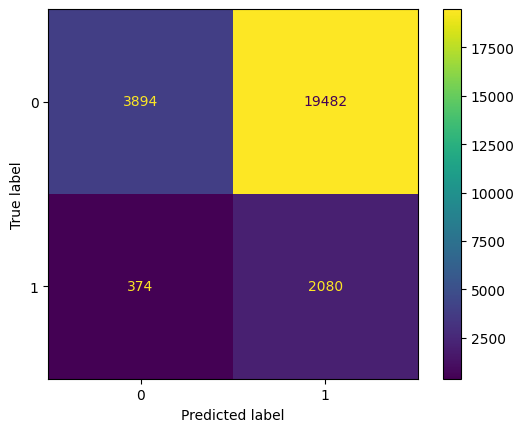

In [6]:
print("LOGISTIC REGRESSION")

print(
    classification_report(
        y_test,
        log_pred
    )
)

cm = confusion_matrix(
    y_test,
    log_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

In [7]:
log_results = {
    "Model": "Logistic Regression",
    "Precision":
        precision_score(y_test, log_pred),
    "Recall":
        recall_score(y_test, log_pred),
    "F1":
        f1_score(y_test, log_pred),
    "ROC_AUC":
        roc_auc_score(y_test, log_prob),
    "AUC_PR":
        average_precision_score(
            y_test,
            log_prob
        )
}

pd.DataFrame([log_results])

,Model,Precision,Recall,F1,ROC_AUC,AUC_PR
0,Logistic Regression,0.096466,0.847596,0.173218,0.500041,0.093736


In [8]:
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

In [9]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="average_precision",
    cv=3,
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

best_rf = grid_search.best_estimator_

print(
    "Best Parameters:",
    grid_search.best_params_
)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [10]:
rf_pred = best_rf.predict(
    X_test
)

rf_prob = best_rf.predict_proba(
    X_test
)[:, 1]

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     23376
           1       0.75      0.58      0.65      2454

    accuracy                           0.94     25830
   macro avg       0.85      0.78      0.81     25830
weighted avg       0.94      0.94      0.94     25830



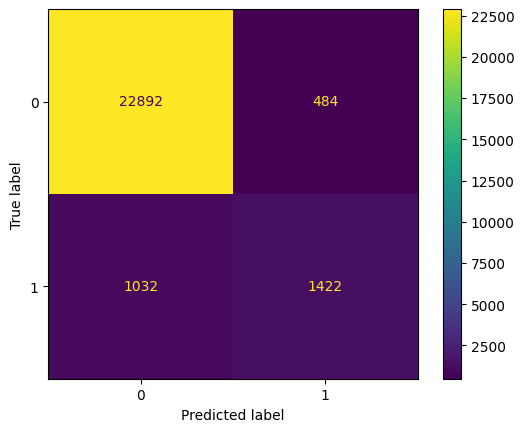

In [11]:
print("RANDOM FOREST")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

cm = confusion_matrix(
    y_test,
    rf_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

In [12]:
rf_results = {
    "Model": "Random Forest",
    "Precision":
        precision_score(y_test, rf_pred),
    "Recall":
        recall_score(y_test, rf_pred),
    "F1":
        f1_score(y_test, rf_pred),
    "ROC_AUC":
        roc_auc_score(y_test, rf_prob),
    "AUC_PR":
        average_precision_score(
            y_test,
            rf_prob
        )
}

pd.DataFrame([rf_results])

,Model,Precision,Recall,F1,ROC_AUC,AUC_PR
0,Random Forest,0.746065,0.579462,0.652294,0.832844,0.691386


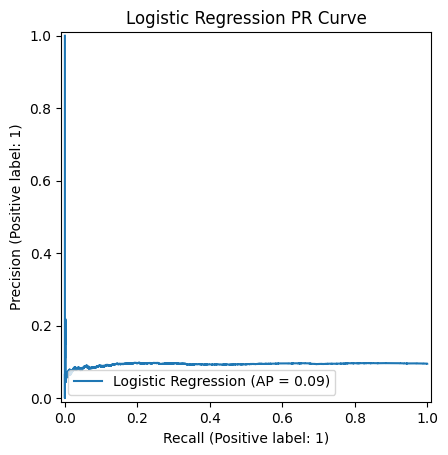

In [13]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    log_prob,
    name="Logistic Regression"
)

plt.title(
    "Logistic Regression PR Curve"
)

plt.show()

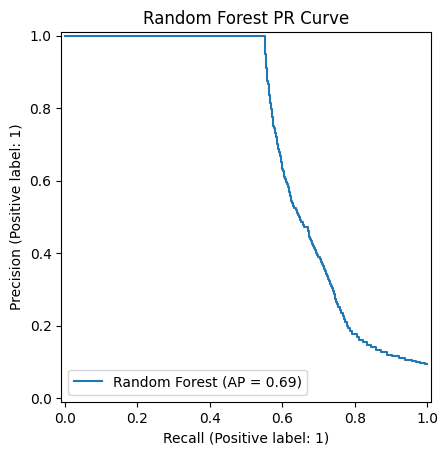

In [14]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest"
)

plt.title(
    "Random Forest PR Curve"
)

plt.show()

In [15]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "f1": "f1",
    "aucpr": "average_precision"
}

In [16]:
log_cv = cross_validate(
    log_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

log_cv_results = {
    "Model":
        "Logistic Regression",
    "CV_F1_Mean":
        log_cv["test_f1"].mean(),
    "CV_F1_Std":
        log_cv["test_f1"].std(),
    "CV_AUC_PR_Mean":
        log_cv["test_aucpr"].mean(),
    "CV_AUC_PR_Std":
        log_cv["test_aucpr"].std()
}

log_cv_results

{'Model': 'Logistic Regression',
 'CV_F1_Mean': np.float64(0.5940630087562807),
 'CV_F1_Std': np.float64(0.07217303288923797),
 'CV_AUC_PR_Mean': np.float64(0.5042174665302118),
 'CV_AUC_PR_Std': np.float64(0.0024325476048743474)}

In [17]:
rf_cv = cross_validate(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

rf_cv_results = {
    "Model":
        "Random Forest",
    "CV_F1_Mean":
        rf_cv["test_f1"].mean(),
    "CV_F1_Std":
        rf_cv["test_f1"].std(),
    "CV_AUC_PR_Mean":
        rf_cv["test_aucpr"].mean(),
    "CV_AUC_PR_Std":
        rf_cv["test_aucpr"].std()
}

rf_cv_results

{'Model': 'Random Forest',
 'CV_F1_Mean': np.float64(0.9537734882713773),
 'CV_F1_Std': np.float64(0.000394544296943431),
 'CV_AUC_PR_Mean': np.float64(0.9888331211984763),
 'CV_AUC_PR_Std': np.float64(0.00027811737574491883)}

In [18]:
metrics_df = pd.DataFrame([
    log_results,
    rf_results
])

cv_df = pd.DataFrame([
    log_cv_results,
    rf_cv_results
])

comparison = metrics_df.merge(
    cv_df,
    on="Model"
)

comparison

,Model,Precision,Recall,F1,ROC_AUC,AUC_PR,CV_F1_Mean,CV_F1_Std,CV_AUC_PR_Mean,CV_AUC_PR_Std
0,Logistic Regression,0.096466,0.847596,0.173218,0.500041,0.093736,0.594063,0.072173,0.504217,0.002433
1,Random Forest,0.746065,0.579462,0.652294,0.832844,0.691386,0.953773,0.000395,0.988833,0.000278


In [19]:
best_model_row = comparison.sort_values(
    by="AUC_PR",
    ascending=False
)

best_model_row

,Model,Precision,Recall,F1,ROC_AUC,AUC_PR,CV_F1_Mean,CV_F1_Std,CV_AUC_PR_Mean,CV_AUC_PR_Std
1,Random Forest,0.746065,0.579462,0.652294,0.832844,0.691386,0.953773,0.000395,0.988833,0.000278
0,Logistic Regression,0.096466,0.847596,0.173218,0.500041,0.093736,0.594063,0.072173,0.504217,0.002433


In [20]:
selected_model = (
    best_rf
    if rf_results["AUC_PR"]
       >= log_results["AUC_PR"]
    else log_model
)

print(
    "Selected Model:",
    type(selected_model).__name__
)

Selected Model: RandomForestClassifier


In [22]:
joblib.dump(
    log_model,
    "../models/logistic_regression.pkl"
)

joblib.dump(
    best_rf,
    "../models/random_forest.pkl"
)

joblib.dump(
    selected_model,
    "../models/best_model.pkl"
)

comparison.to_csv(
    "../models/model_comparison.csv",
    index=False
)

print("Artifacts Saved")

Artifacts Saved


## Model Selection

Logistic Regression was used as the interpretable baseline model.

Random Forest achieved superior fraud detection performance based on AUC-PR, F1 Score, and cross-validation results.

Since fraud detection is an imbalanced classification problem, AUC-PR was prioritized as the primary evaluation metric.

Therefore, Random Forest was selected as the final model.